# We’re not doing random analysis.
# We will answer business questions

In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

#importing CSV file
import pandas as pd
df = pd.read_csv("retail_customer_segmentation.csv")

In [4]:
#displaying the available columns
df.isnull().sum()
df.columns

Index(['customer_id', 'age', 'annual_income', 'months_active',
       'avg_monthly_spend', 'purchase_frequency', 'avg_order_value',
       'discount_usage_rate', 'return_rate', 'browsing_time_minutes',
       'support_interactions', 'payment_method', 'region', 'customer_segment'],
      dtype='object')

In [6]:
# beginning of data cleaning
# Basic checks to check for missing values etc.
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

# As you can see here there are a lot of missing values now. So how do we tackle this problem?

# If we use df.dropna() function then we would lose half of our data, so to overcome this we will fill the missing values and change floating point values to integer type values

In [10]:
#filling numerical values
df.fillna({
    "age": df["age"].median(),
    "annual_income": df["annual_income"].median(),
    "avg_monthly_spend": df["avg_monthly_spend"].median(),
    "purchase_frequency": df["purchase_frequency"].median(),
    "avg_order_value": df["avg_order_value"].median(),
    "discount_usage_rate": df["discount_usage_rate"].median(),
    "return_rate": df["return_rate"].median(),
    "browsing_time_minutes": df["browsing_time_minutes"].median(),
    "support_interactions": df["support_interactions"].median()
}, inplace=True)

#checking again (all the missing values should be 0)
df.isnull().sum()

customer_id              0
age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

In [12]:
#converting floating type values to integer type values cleanly
df["age"] = df["age"].astype(int)
df["months_active"] = df["months_active"].astype(int)

# Finally Our data is usable

In [15]:
#storing in sql
import sqlite3
conn = sqlite3.connect("customer.db")
df.to_sql("customers", conn, if_exists="replace", index=False)

50000

# That 5000 is the return value of df.to_sql()
It means: 5000 rows were successfully inserted into the SQL table

# A big catch here!! If you try to directly execute sql code it wont work You MUST wrap SQL inside a string and use pd.read_sql()

In [19]:
#Demo
SELECT customer_segment, 
       AVG(avg_monthly_spend) as avg_spend,
       AVG(purchase_frequency) as avg_freq
FROM customers
GROUP BY customer_segment
ORDER BY avg_spend DESC;

SyntaxError: invalid syntax (1228390988.py, line 2)

# Now we start with data analysis part. We will analyze the following 
    1. Customer Segmentation
    2. Purchase Behavior   
    3. High-Value Customers
    4. Income vs Spending
    5. Discount Analysis
    6. Return Behavior   
    7. Engagement Analysis
    8. Region Analysis   
        

In [22]:
#Customer segmentation impact
query1 = """
SELECT customer_segment,
       AVG(avg_monthly_spend) as avg_spend,
       AVG(purchase_frequency) as avg_freq
FROM customers
GROUP BY customer_segment
ORDER BY avg_spend DESC;
"""

result = pd.read_sql(query1, conn)
result

,customer_segment,avg_spend,avg_freq
0,High_Value,463.772525,8.449188
1,Occasional,381.596124,3.301483
2,Regular,270.160162,4.810821
3,Loyal,245.245798,6.742210


In [24]:
# Purchase Behavior Analysis
query_freq = """
SELECT customer_segment, AVG(purchase_frequency) as avg_frequency
FROM customers
GROUP BY customer_segment
ORDER BY avg_frequency DESC;
"""

freq_analysis = pd.read_sql(query_freq, conn)
freq_analysis

,customer_segment,avg_frequency
0,High_Value,8.449188
1,Loyal,6.742210
2,Regular,4.810821
3,Occasional,3.301483


In [26]:
#High-Value Customers (TOP SPENDERS)
#Question to be answered here~ Who are your most valuable customers
query2 = """
SELECT customer_id, avg_monthly_spend, annual_income
FROM customers
ORDER BY avg_monthly_spend DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query2, conn)
top_customers

,customer_id,avg_monthly_spend,annual_income
0,21521,3026.342238,36106.206662
1,21297,3019.228652,36332.169469
2,49880,2921.206351,32074.757694
3,5668,2753.108202,38080.207951
4,44615,2736.179066,27766.772535
5,37569,2710.575654,23865.414611
6,13663,2397.276989,36787.730010
7,9903,2368.735232,82393.015022
8,18542,2229.921649,27196.059988
9,37013,2192.842055,17173.212301


In [28]:
# Income vs Spending
query_income = """
SELECT 
    CASE 
        WHEN annual_income < 30000 THEN 'Low Income'
        WHEN annual_income BETWEEN 30000 AND 70000 THEN 'Medium Income'
        ELSE 'High Income'
    END as income_group,
    AVG(avg_monthly_spend) as avg_spend
FROM customers
GROUP BY income_group;
"""

income_analysis = pd.read_sql(query_income, conn)
income_analysis

,income_group,avg_spend
0,High Income,334.673920
1,Low Income,337.002998
2,Medium Income,334.297909


In [30]:
#Discount Behavior
# Question to be answered here~ Do discounts increase spending or not?
query3 = """
SELECT 
    CASE 
        WHEN discount_usage_rate > 0.5 THEN 'High Discount Users'
        ELSE 'Low Discount Users'
    END as discount_group,
    AVG(avg_monthly_spend) as avg_spend
FROM customers
GROUP BY discount_group;
"""

discount_analysis = pd.read_sql(query3, conn)
discount_analysis

,discount_group,avg_spend
0,High Discount Users,338.091742
1,Low Discount Users,334.968318


In [32]:
# Return Behavior
query_return = """
SELECT customer_segment, AVG(return_rate) as avg_return
FROM customers
GROUP BY customer_segment
ORDER BY avg_return DESC;
"""

return_analysis = pd.read_sql(query_return, conn)
return_analysis

,customer_segment,avg_return
0,Loyal,0.149095
1,High_Value,0.148053
2,Occasional,0.147640
3,Regular,0.146725


In [34]:
#Engagement vs Spending
# Question to be answered here~ Do more engaged users spend more?
query4 = """
SELECT 
    CASE 
        WHEN browsing_time_minutes > 200 THEN 'High Engagement'
        ELSE 'Low Engagement'
    END as engagement_group,
    AVG(avg_monthly_spend) as avg_spend
FROM customers
GROUP BY engagement_group;
"""

engagement_analysis = pd.read_sql(query4, conn)
engagement_analysis


,engagement_group,avg_spend
0,High Engagement,341.050242
1,Low Engagement,335.237597


In [36]:
# Region-wise Analysis
query_region = """
SELECT region, AVG(avg_monthly_spend) as avg_spend
FROM customers
GROUP BY region
ORDER BY avg_spend DESC;
"""

region_analysis = pd.read_sql(query_region, conn)
region_analysis

,region,avg_spend
0,Urban,335.838889
1,Semi-Urban,334.819623
2,Rural,334.632660


## Key Insights

- High-value customers contribute the highest revenue, but loyalty does not always translate to higher spending.
- High spending is not strictly dependent on income — mid-income users can also be high-value customers.
- Discounts have minimal impact on increasing customer spending, indicating limited effectiveness.
- Higher user engagement (browsing time) is positively correlated with increased spending.

# Our next step includes visualization

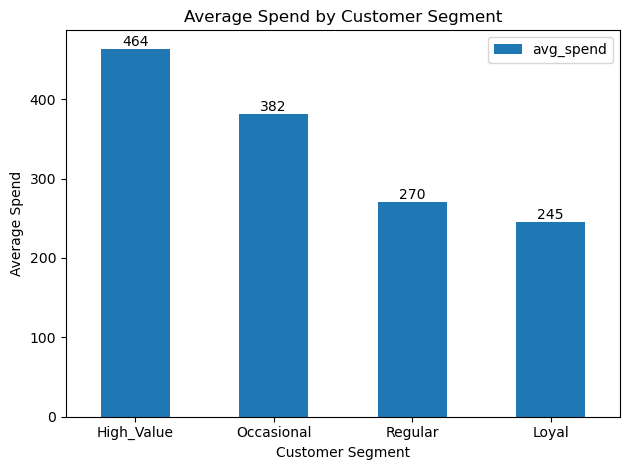

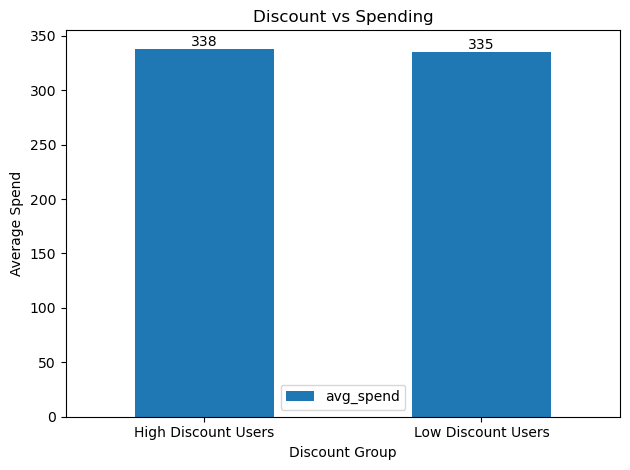

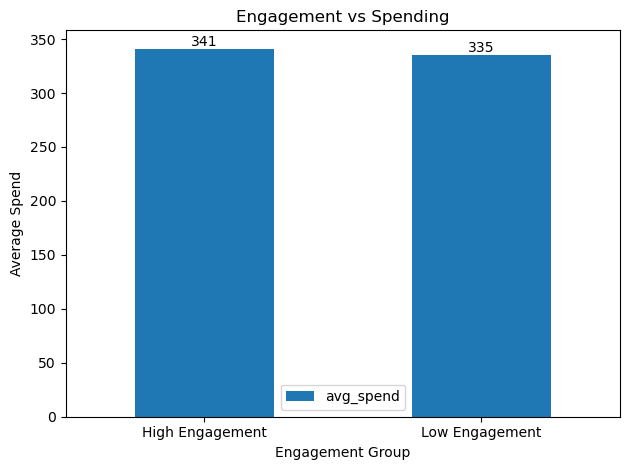

In [44]:
# 1. Segment vs Spend
ax = result.plot(x="customer_segment", y="avg_spend", kind="bar")

plt.title("Average Spend by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spend")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 2. Discount Impact
ax = discount_analysis.plot(x="discount_group", y="avg_spend", kind="bar")

plt.title("Discount vs Spending")
plt.xlabel("Discount Group")
plt.ylabel("Average Spend")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. Engagement Impact
ax = engagement_analysis.plot(x="engagement_group", y="avg_spend", kind="bar")

plt.title("Engagement vs Spending")
plt.xlabel("Engagement Group")
plt.ylabel("Average Spend")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

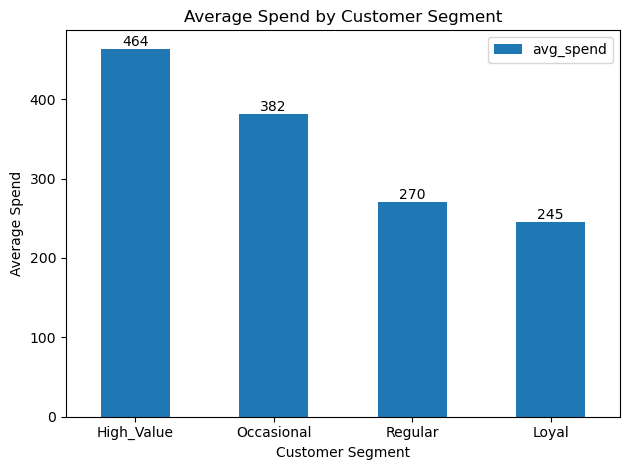

In [48]:
#Instead of a big code we can use this reuseable function to plot everything
def plot_bar(df, x_col, y_col, title, xlabel, ylabel):
    ax = df.plot(x=x_col, y=y_col, kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    for p in ax.patches:
        ax.annotate(f"{p.get_height():.0f}", 
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_bar(result, "customer_segment", "avg_spend",
         "Average Spend by Customer Segment",
         "Customer Segment", "Average Spend")

In [50]:
df.to_csv("cleaned_customer_data.csv", index=False)